In [1]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal
from sklearn.preprocessing import StandardScaler

from emcee import EnsembleSampler
from trianglechain import TriangleChain

from msi import emulator
from msfm.utils import prior, parameters

23-06-26 05:33:57    scales.py INF   Setting up healpy to run on 256 CPUs 


# network predictions

In [2]:
def load_preds(base_dir, model_dir, n_steps=None, file_label=None):
    out_dir = os.path.join(base_dir, model_dir)
    
    if n_steps is None:
        preds_file = os.path.join(out_dir, f"preds.h5")
    elif file_label is None:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")
    else:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}_{file_label}.h5")

    with h5py.File(preds_file, "r") as f:
        # fiducial
        fidu_train_preds = f["fiducial/train/pred"][:]
        fidu_vali_preds = f["fiducial/vali/pred"][:]

        print(f"fidu_train_preds =   {fidu_train_preds.shape}")
        print(f"fidu_vali_preds =    {fidu_vali_preds.shape}")

        # grid
        grid_preds = f["grid/pred"][:]
        grid_cosmos = f["grid/cosmo"][:]
        grid_sobol = f["grid/i_sobol"][:]
        print(f"grid_preds.shape =   {grid_preds.shape}")
        print(f"grid_cosmos.shape =  {grid_cosmos.shape}")
        print(f"grid_sobol.shape =   {grid_cosmos.shape}")

    return fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol

### choose a run

In [3]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3"

In [4]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

In [5]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [6]:
# # lensing only
# model_dir = "2023-05-29_09-55-49_resnet_vanilla"
# n_steps = 50000

# param_labels = ["Om", "s8", "Aia", "n_Aia"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

In [7]:
# combined probes
model_dir = "2023-05-30_10-56-53_resnet_vanilla"
n_steps = 10000

param_labels = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]
param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$', r'$b_g$', r'$\eta_{b_g}$']
fiducial_point = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5, "bg": 1.5, "n_bg": 0.5}

fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

fidu_train_preds =   (750, 6)
fidu_vali_preds =    (50, 6)
grid_preds.shape =   (2499, 16, 6)
grid_cosmos.shape =  (2499, 6)
grid_sobol.shape =   (2499, 6)


In [8]:
n_params = len(param_labels)
assert n_params == fidu_train_preds.shape[-1] == grid_preds.shape[-1]

obs_pred = np.median(fidu_vali_preds, axis=0)

# scale everything
# cosmo_scaler = StandardScaler().fit()

# Gaussian likelihood

### Covariance

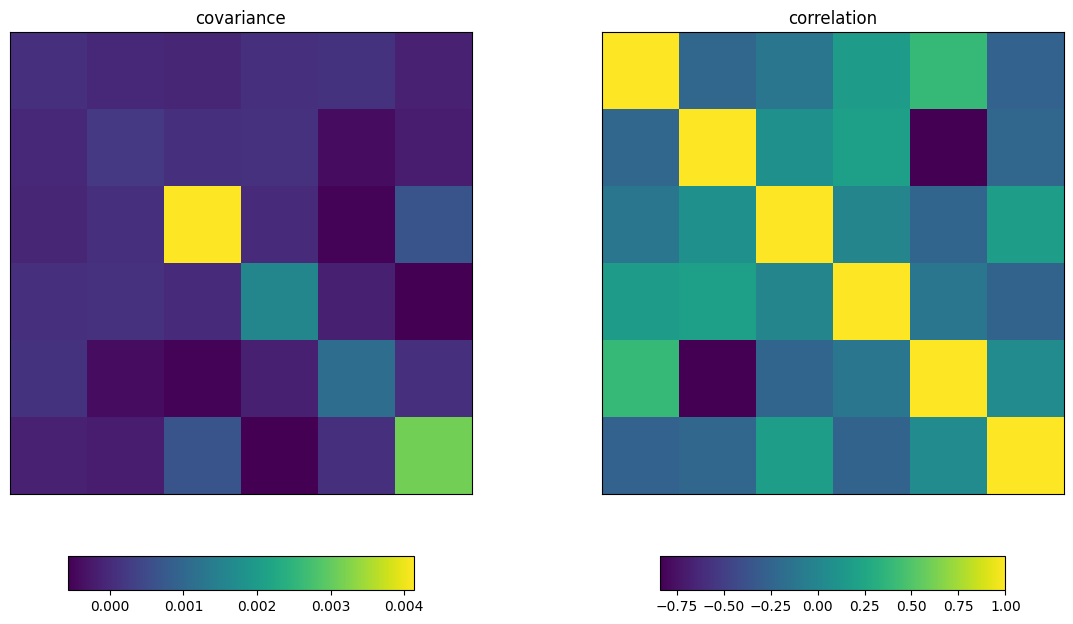

In [9]:
fid_cov = np.cov(fidu_vali_preds, rowvar=False)
fid_corr = np.corrcoef(fidu_vali_preds, rowvar=False)

fig, ax = plt.subplots(figsize=(14,8), ncols=2)

# covariance
im = ax[0].imshow(fid_cov)
ax[0].set(title="covariance")
ax[0].set_xticks([])
ax[0].set_yticks([])

fig.colorbar(im, ax=ax[0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[1].imshow(fid_corr)
ax[1].set(title="correlation")
ax[1].set_xticks([])
ax[1].set_yticks([])

fig.colorbar(im, ax=ax[1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

### dense network

In [10]:
split_index = -2

y_train = np.concatenate(grid_preds[:,:split_index,:], axis=0)
x_train = np.repeat(grid_cosmos, y_train.shape[0]//grid_cosmos.shape[0], axis=0)

print(y_train.shape)
print(x_train.shape)

y_vali = np.concatenate(grid_preds[:,split_index:,:], axis=0)
x_vali = np.repeat(grid_cosmos, y_vali.shape[0]//grid_cosmos.shape[0], axis=0)

print(x_vali.shape)
print(y_vali.shape)

(34986, 6)
(34986, 6)
(4998, 6)
(4998, 6)


Epoch 1/1000
137/137 [==============================] - 1s 3ms/step - loss: 0.2430 - val_loss: 0.0899
Epoch 2/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.0907 - val_loss: 0.0637
Epoch 3/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.0694 - val_loss: 0.0506
Epoch 4/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.0560 - val_loss: 0.0389
Epoch 5/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.0473 - val_loss: 0.0323
Epoch 6/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.0430 - val_loss: 0.0266
Epoch 7/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.0400 - val_loss: 0.0271
Epoch 8/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.0397 - val_loss: 0.0251
Epoch 9/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.0372 - val_loss: 0.0241
Epoch 10/1000
137/137 [==============================] - 0s 2ms/step - loss: 0.034

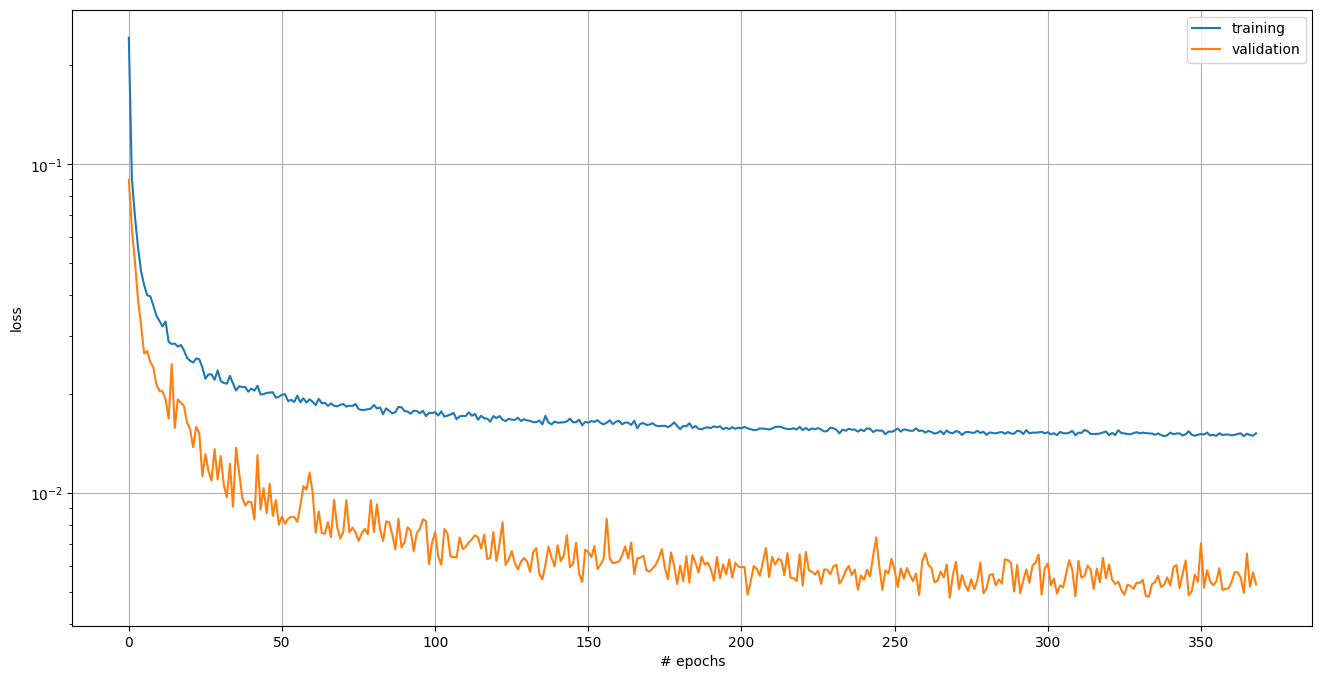

In [11]:
emu = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),    
    tf.keras.layers.Dense(256, activation='relu'),    
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(n_params)
])

emu.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
)

history = emu.fit(
    x=x_train,
    y=y_train,
    batch_size=256,
    epochs=1000,
    validation_data=(x_vali, y_vali),
    shuffle=True,
    callbacks=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True),
    verbose=1,
)

fig, ax = plt.subplots(figsize=(16,8))

ax.plot(history.history["loss"], label="training")
ax.plot(history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="log")
ax.grid(True)

# MCMC

In [12]:
tf_cholesky = tf.linalg.cholesky(tf.cast(fid_cov, dtype=tf.float32))
tf_pred = tf.cast(obs_pred, dtype=tf.float32)

def log_posterior(X): 
    normal = tfp.distributions.MultivariateNormalTriL(
        loc=emu(X), 
        scale_tril=tf_cholesky,
    )

    # evaluate the normal distribution
    log_prob = normal.log_prob(tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=param_labels, conf=None)

    return log_prob

In [13]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
p0 = np.random.normal(loc=parameters.get_fiducials(param_labels), scale=1e-3, size=(nwalkers, n_params))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=param_labels))) 

Initial values in prior:  True


In [14]:
# sample burn in
sampler = EnsembleSampler(nwalkers, n_params, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()

# run the actual chain
sampler.run_mcmc(state, 1000, progress=True)

# save the result
chain = sampler.get_chain(flat=True)
np.save(os.path.join(base_dir, model_dir, f"chain_{n_steps}_normal.npy"), chain)

100%|██████████| 1000/1000 [01:14<00:00, 13.39it/s]


# plot

### compare GP ABC to normalizing flow

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

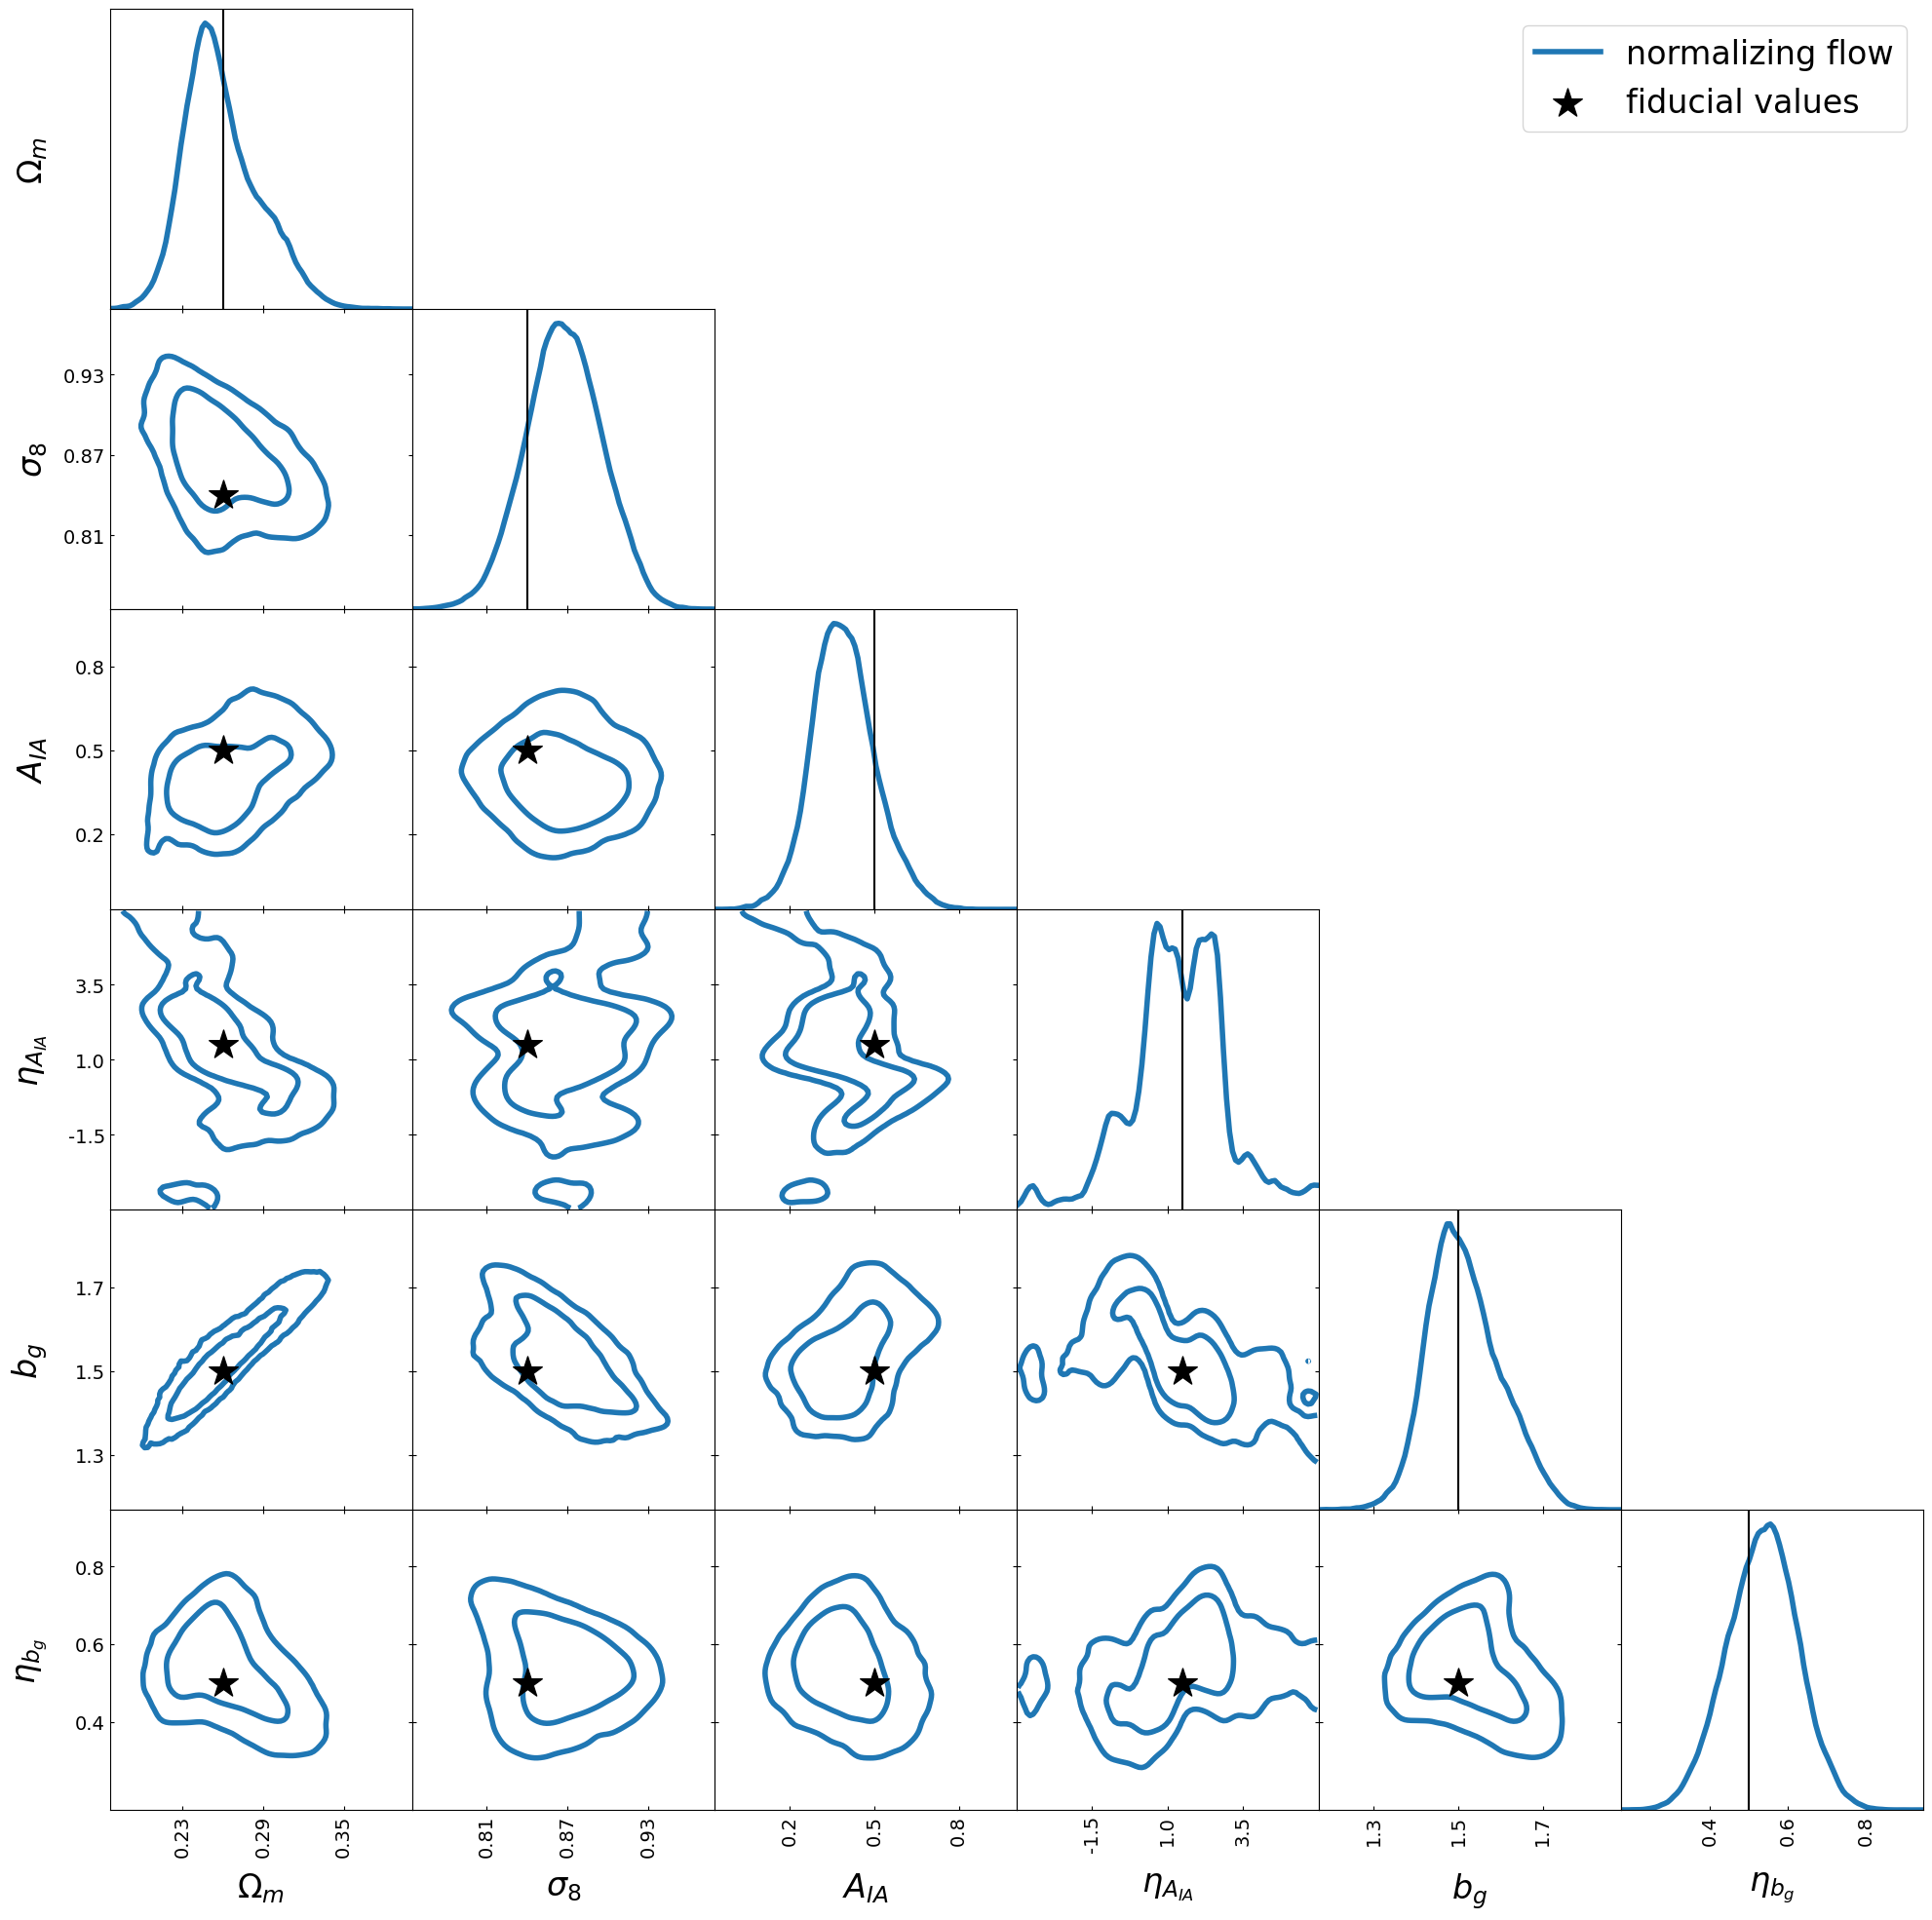

In [15]:
tri = TriangleChain(labels=param_latex, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})

# Gaussian likelihood
tri.contour_cl(chain, names=param_labels, label="normalizing flow")

# fiducial
tri.scatter(
    fiducial_point,
    label="fiducial values",
    plot_histograms_1D=False,
    color="k",
    show_legend=True,
    scatter_vline_1D=True,
)
tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_normal.png"), bbox_inches="tight", dpi=300)

### compare with and without survey systematics correction

In [16]:
# tri = TriangleChain(labels=param_labels, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})

# # with systematics
# chain = np.load(os.path.join(base_dir, model_dir, f"chain_{n_steps}_flow_survey_systematics.npy"))
# tri.contour_cl(chain, names=param_labels, label="flow, with survey systematics")

# # without systematics
# chain = np.load(os.path.join(base_dir, model_dir, f"chain_{n_steps}_flow_no_survey_systematics.npy"))
# tri.contour_cl(chain, names=param_labels, label="flow, without survey systematics")

# # fiducial
# tri.scatter(
#     fiducial_point,
#     label="fiducial values",
#     plot_histograms_1D=False,
#     color="k",
#     show_legend=True,
#     scatter_vline_1D=True,
# )
# tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_flow_systematics.png"), bbox_inches="tight", dpi=300)